## Load Model Ready Data 

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

PROJECT_DIR = Path.cwd().parent
PROCESSED_DATA_DIR = (
    PROJECT_DIR / "data" / "processed")
X_path = (
    PROCESSED_DATA_DIR /
    "geolife_model_features.parquet")

metadata_path = (
    PROCESSED_DATA_DIR /
    "geolife_model_metadata.parquet")

X = pd.read_parquet(X_path)
metadata = pd.read_parquet(metadata_path)

print("X shape:", X.shape)
print("Metadata shape:", metadata.shape)
print(X.head())

X shape: (916, 10)
Metadata shape: (916, 10)
   time_gap_seconds  distance_from_previous_m  speed_kmh  distance_to_road_m  \
0               NaN                 -0.193320        NaN           -0.478547   
1         -0.042827                 -0.151800  -0.589361           -0.610000   
2         -0.044429                 -0.159849  -0.596199           -0.583825   
3         -0.044429                 -0.160981  -0.603061           -0.564423   
4         -0.044429                 -0.063056  -0.009621           -0.757763   

     length  rolling_speed_mean_5  rolling_speed_std_5  \
0 -0.117695                   NaN            -0.438759   
1 -0.117695             -0.954357            -0.438759   
2 -0.117695             -0.959900            -0.432760   
3 -0.117695             -0.965458            -0.430260   
4 -0.117695             -0.727652            -0.074788   

   rolling_road_distance_mean_5  rolling_gps_jump_count_5  \
0                     -0.504862                 -0.074084   
1  

# Create Isolation Forest

In [2]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1)

# Train Model

In [3]:
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


# Anomaly prediction

In [4]:
predictions = model.predict(X)
print(np.unique(predictions, return_counts=True))

(array([-1,  1]), array([ 86, 830]))


In [ ]:
metadata["anomaly_flag"] = predictions
print(
    metadata["anomaly_flag"]
    .value_counts()) #1 is normal an -1 is anomaly 

anomaly_flag
 1    830
-1     86
Name: count, dtype: int64


# Anomaly Percentage

In [6]:
anomaly_count = (
    metadata["anomaly_flag"] == -1
).sum()

total_count = len(metadata)
anomaly_percentage = (
    anomaly_count / total_count) * 100

print("Total points:", total_count)
print("Anomalies:", anomaly_count)
print(
    f"Anomaly percentage: {anomaly_percentage:.2f}%")

Total points: 916
Anomalies: 86
Anomaly percentage: 9.39%


GeoLife is a normal human movement dataset, not a VigiloX-labeled guard incident dataset.

Therefore, the first output of Isolation Forest is only:

Baseline Anomaly Detection Result

# Anomaly Score

In [8]:
# -1/1 is not enough 
metadata["anomaly_score"] = -model.score_samples(X)
print(
    metadata["anomaly_score"].describe())

count    916.000000
mean       0.420796
std        0.053307
min        0.373010
25%        0.386320
50%        0.401315
75%        0.433440
max        0.761362
Name: anomaly_score, dtype: float64


# Top Suspicious Events 

In [9]:
top_anomalies = (
    metadata
    .sort_values(
        "anomaly_score",
        ascending=False
    ).head(20))

print(
    top_anomalies[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "anomaly_score",
            "anomaly_flag",
            "gps_jump",
            "road_match_status",
            "long_time_gap",
            "high_speed",
            "road_deviation",
            "rule_anomaly_count"
        ]])

    guard_id           timestamp   latitude   longitude  anomaly_score  \
150      000 2008-10-23 04:08:42  39.984397  116.299292       0.761362   
151      000 2008-10-23 04:08:47  39.984426  116.299329       0.700757   
152      000 2008-10-23 04:08:52  39.984499  116.299413       0.694744   
149      000 2008-10-23 04:08:12  39.996832  116.285446       0.681097   
148      000 2008-10-23 04:08:07  39.995777  116.286798       0.673312   
470      000 2008-10-23 09:42:25  40.004775  116.320158       0.670226   
153      000 2008-10-23 04:08:57  39.984424  116.299467       0.652535   
794      000 2008-10-23 10:26:35  40.006747  116.318549       0.630193   
154      000 2008-10-23 04:09:02  39.984410  116.299477       0.625664   
883      000 2008-10-23 10:44:41  40.008650  116.323112       0.622567   
881      000 2008-10-23 10:44:31  40.008761  116.323722       0.621841   
769      000 2008-10-23 10:19:16  40.007645  116.319454       0.621091   
184      000 2008-10-23 04:11:22  39.9

# Assign Anomaly Types

In [10]:
def classify_anomaly(row):
    if row["long_time_gap"]:
        return "TIMING_ANOMALY"
    if row["gps_jump"]:
        return "GPS_ANOMALY"
    if row["road_deviation"]:
        return "ROUTE_DEVIATION"
    if row["high_speed"]:
        return "SPEED_ANOMALY"
    return "BEHAVIORAL_ANOMALY"

# Apply 

In [12]:
metadata["anomaly_type"] = np.where(
    metadata["anomaly_flag"] == -1,
    metadata.apply(classify_anomaly, axis=1),
    "NORMAL")

# Severity

In [13]:
def assign_severity(score):
    if score >= 0.70:
        return "CRITICAL"
    elif score >= 0.55:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    return "LOW"

 This threshold is not final later we will tune it against labeled incidents 

In [14]:
metadata["severity"] = np.where(
    metadata["anomaly_flag"] == -1,
    metadata["anomaly_score"].apply(assign_severity),
    "NORMAL")

# Final Anomaly Report 

In [15]:
anomaly_report = metadata[
    metadata["anomaly_flag"] == -1
].copy()

print(
    anomaly_report[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "anomaly_score",
            "anomaly_type",
            "severity",
            "rule_anomaly_count"
        ]  ].head(20))

    guard_id           timestamp   latitude   longitude  anomaly_score  \
28       000 2008-10-23 02:55:25  39.984618  116.314323       0.528623   
148      000 2008-10-23 04:08:07  39.995777  116.286798       0.673312   
149      000 2008-10-23 04:08:12  39.996832  116.285446       0.681097   
150      000 2008-10-23 04:08:42  39.984397  116.299292       0.761362   
151      000 2008-10-23 04:08:47  39.984426  116.299329       0.700757   
152      000 2008-10-23 04:08:52  39.984499  116.299413       0.694744   
153      000 2008-10-23 04:08:57  39.984424  116.299467       0.652535   
154      000 2008-10-23 04:09:02  39.984410  116.299477       0.625664   
184      000 2008-10-23 04:11:22  39.983841  116.299902       0.602818   
185      000 2008-10-23 04:11:27  39.983861  116.300177       0.512622   
186      000 2008-10-23 04:11:32  39.983842  116.300329       0.501985   
187      000 2008-10-23 04:11:37  39.983984  116.300308       0.512388   
188      000 2008-10-23 04:11:42  39.9

# Anomaly Distribution 

In [16]:
print(
    anomaly_report["anomaly_type"]
    .value_counts())

anomaly_type
BEHAVIORAL_ANOMALY    42
ROUTE_DEVIATION       35
TIMING_ANOMALY         6
SPEED_ANOMALY          2
GPS_ANOMALY            1
Name: count, dtype: int64


In [17]:
print(
    anomaly_report["severity"]
    .value_counts())

severity
MEDIUM      52
HIGH        32
CRITICAL     2
Name: count, dtype: int64


# Save Result 

In [18]:
output_path = (
    PROCESSED_DATA_DIR /
    "geolife_isolation_forest_results.parquet")

metadata.to_parquet(
    output_path,
    index=False)

print("Saved:", output_path)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_isolation_forest_results.parquet


# Anomaly-specific features

Long time gap

High speed

Large GPS jump

Large distance from road

Unusual road distance

Patrol movement inactivity

Combined risk indicators

median time gap = 5 sec

max = 18,453 sec

Therefore, we will **not directly classify the raw `time_gap_seconds` as an anomaly**. First, we will **define an appropriate threshold**.


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path.cwd().parent

INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True)

input_path = (
    INTERIM_DATA_DIR /
    "geolife_gps_osm_features.parquet")

df = pd.read_parquet(input_path)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Shape: (916, 14)
Columns:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


In [22]:
df["long_time_gap"] = (
    df["time_gap_seconds"] > 60
)
#If there is a gap of **more than 60 seconds between two consecutive GPS points, mark that point as a long-gap candidate.**

# High Speed Flag

In current data, the maximum speed is 218 km/h.

For guard walking/patrol data, this speed could be considered suspicious.

In [ ]:
df["high_speed"] = (
    df["speed_kmh"] > 15)
# 15 km/h is not final business threshold 

# Road-deviation flag

In [24]:
df["large_road_deviation"] = (
    df["distance_to_road_m"] > 50)

# GPS jump flag

In [25]:
df["gps_jump"].value_counts()

gps_jump
False    915
True       1
Name: count, dtype: int64

# Explicit Numeric Flag 

In [26]:
df["gps_jump_flag"] = (
    df["gps_jump"] == True
).astype(int)

# Combined Anomaly Candidates

In [28]:
df["anomaly_signal_count"] = (
    df["long_time_gap"].astype(int)
    + df["high_speed"].astype(int)
    + df["large_road_deviation"].astype(int)
    + df["gps_jump_flag"])

print(
    df["anomaly_signal_count"]
    .value_counts()
    .sort_index())

anomaly_signal_count
0    791
1    117
2      8
Name: count, dtype: int64


0 → No obvious anomaly signal
1 → One suspicious signal
2 → Two suspicious signals
3 → Three suspicious signals
4 → Multiple strong signals

For now, this should not be called a final anomaly label. It is only a candidate signal.

# Check Result

In [29]:
print(
    df[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "gps_jump",
            "long_time_gap",
            "high_speed",
            "large_road_deviation",
            "anomaly_signal_count"
        ]].head(20))

   guard_id           timestamp  speed_kmh  time_gap_seconds  \
0       000 2008-10-23 02:53:04        NaN               NaN   
1       000 2008-10-23 02:53:10   2.112417               6.0   
2       000 2008-10-23 02:53:15   2.043534               5.0   
3       000 2008-10-23 02:53:20   1.974399               5.0   
4       000 2008-10-23 02:53:25   7.952992               5.0   
5       000 2008-10-23 02:53:30  14.993339               5.0   
6       000 2008-10-23 02:53:35  16.298570               5.0   
7       000 2008-10-23 02:53:40  15.430589               5.0   
8       000 2008-10-23 02:53:45  13.847494               5.0   
9       000 2008-10-23 02:53:50  15.067123               5.0   
10      000 2008-10-23 02:53:55   9.945908               5.0   
11      000 2008-10-23 02:54:00  12.078024               5.0   
12      000 2008-10-23 02:54:05  11.793594               5.0   
13      000 2008-10-23 02:54:10  10.825155               5.0   
14      000 2008-10-23 02:54:15  10.2613

##  Existing anomaly signals

# Severity Rules

We will use simple and explainable rules:

| Condition     | Severity |
| ------------- | -------- |
| 1 weak signal | LOW      |
| 2 signals     | MEDIUM   |
| 3 signals     | HIGH     |
| 4 signals     | CRITICAL |


However, strong individual anomalies will also be assigned a higher severity.

# For example:

GPS > 100 m from road → HIGH

GPS > 200 m from road → CRITICAL

Speed > 30 km/h → HIGH

Speed > 50 km/h → CRITICAL

Time gap > 5 min → HIGH

Time gap > 15 min → CRITICAL

# Create String Signals

In [30]:
df["extreme_speed"] = (
    df["speed_kmh"] > 50)

df["very_high_speed"] = (
    df["speed_kmh"] > 30)

df["extreme_road_deviation"] = (
    df["distance_to_road_m"] > 200)

df["very_large_road_deviation"] = (
    df["distance_to_road_m"] > 100)

df["critical_time_gap"] = (
    df["time_gap_seconds"] > 900)

df["high_time_gap"] = (
    df["time_gap_seconds"] > 300)

# Signal Count

In [31]:
df["anomaly_signal_count"] = (
    df["long_time_gap"].astype(int)
    + df["high_speed"].astype(int)
    + df["large_road_deviation"].astype(int)
    + df["gps_jump_flag"])

# Calculate severity

In [33]:
def calculate_severity(row):
    # Critical individual anomaly
    if (
        row["extreme_speed"]
        or row["extreme_road_deviation"]
        or row["critical_time_gap"]
    ):
        return "CRITICAL"
    # High individual anomaly
    if (
        row["very_high_speed"]
        or row["very_large_road_deviation"]
        or row["high_time_gap"]
    ):
        return "HIGH"
    # Multiple anomaly signals
    if row["anomaly_signal_count"] >= 3:
        return "HIGH"
    if row["anomaly_signal_count"] == 2:
        return "MEDIUM"
    if row["anomaly_signal_count"] == 1:
        return "LOW"
    return "NORMAL"

df["severity"] = df.apply(
    calculate_severity,
    axis=1)

print(
    df["severity"]
    .value_counts()
    .sort_index())

severity
CRITICAL      9
HIGH          5
LOW         105
MEDIUM        6
NORMAL      791
Name: count, dtype: int64


In [34]:
print(
    df[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "gps_jump",
            "anomaly_signal_count",
            "severity"
        ]].head(30))

   guard_id           timestamp  speed_kmh  time_gap_seconds  \
0       000 2008-10-23 02:53:04        NaN               NaN   
1       000 2008-10-23 02:53:10   2.112417               6.0   
2       000 2008-10-23 02:53:15   2.043534               5.0   
3       000 2008-10-23 02:53:20   1.974399               5.0   
4       000 2008-10-23 02:53:25   7.952992               5.0   
5       000 2008-10-23 02:53:30  14.993339               5.0   
6       000 2008-10-23 02:53:35  16.298570               5.0   
7       000 2008-10-23 02:53:40  15.430589               5.0   
8       000 2008-10-23 02:53:45  13.847494               5.0   
9       000 2008-10-23 02:53:50  15.067123               5.0   
10      000 2008-10-23 02:53:55   9.945908               5.0   
11      000 2008-10-23 02:54:00  12.078024               5.0   
12      000 2008-10-23 02:54:05  11.793594               5.0   
13      000 2008-10-23 02:54:10  10.825155               5.0   
14      000 2008-10-23 02:54:15  10.2613

# Visualize Severity Distribution

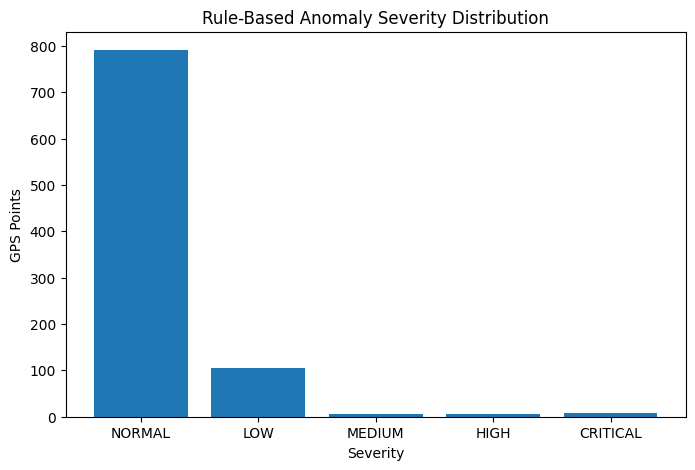

In [35]:
import matplotlib.pyplot as plt
severity_counts = (
    df["severity"]
    .value_counts()
    .reindex(
        ["NORMAL", "LOW", "MEDIUM", "HIGH", "CRITICAL"],
        fill_value=0))

plt.figure(figsize=(8, 5))
plt.bar(
    severity_counts.index,
    severity_counts.values)

plt.xlabel("Severity")
plt.ylabel("GPS Points")
plt.title("Rule-Based Anomaly Severity Distribution")

plt.show()

# Rule Based Anomaly Score 

We will convert current signals into weighted score 

In [36]:
df["rule_anomaly_score"] = (
    0.25 * df["long_time_gap"].astype(int)
    + 0.25 * df["high_speed"].astype(int)
    + 0.25 * df["large_road_deviation"].astype(int)
    + 0.25 * df["gps_jump_flag"])

0.00 → No rule anomaly

0.25 → 1 anomaly signal

0.50 → 2 signals

0.75 → 3 signals

1.00 → 4 signals

# Verify String Anomalies

In [37]:
print(
    df[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "gps_jump",
            "rule_anomaly_score",
            "severity"
        ]
    ].sort_values(
        "rule_anomaly_score",
        ascending=False ).head(20))

    guard_id           timestamp   speed_kmh  time_gap_seconds  \
823      000 2008-10-23 10:28:45   22.530987              10.0   
769      000 2008-10-23 10:19:16   61.286863               5.0   
738      000 2008-10-23 10:14:31   17.142172               5.0   
737      000 2008-10-23 10:14:26   24.660005               5.0   
743      000 2008-10-23 10:15:06   19.224082              15.0   
739      000 2008-10-23 10:14:36   16.349874               5.0   
685      000 2008-10-23 10:09:26   25.242124              10.0   
150      000 2008-10-23 04:08:42  218.147174              30.0   
834      000 2008-10-23 10:29:35    7.901409               5.0   
28       000 2008-10-23 02:55:25   41.891857               5.0   
6        000 2008-10-23 02:53:35   16.298570               5.0   
7        000 2008-10-23 02:53:40   15.430589               5.0   
20       000 2008-10-23 02:54:45   15.113180               5.0   
829      000 2008-10-23 10:29:10    3.308406               5.0   
830      0

# ML Feature Selection 

# Initial Features

In [38]:
ml_features = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length",
    "gps_jump_flag",
    "rule_anomaly_score"
]

In [39]:
print(df[ml_features].describe())

       time_gap_seconds  distance_from_previous_m   speed_kmh  \
count        915.000000                916.000000  915.000000   
mean          32.724590                 16.392717    8.049921   
std          624.355707                 84.842050   10.079986   
min            1.000000                  0.000000    0.000000   
25%            5.000000                  4.665800    3.270079   
50%            5.000000                 10.494398    7.307210   
75%            5.000000                 16.027460   11.412784   
max        18453.000000               1817.893113  218.147174   

       distance_to_road_m       length  gps_jump_flag  rule_anomaly_score  
count          916.000000   916.000000     916.000000          916.000000  
mean            13.579800   453.228166       0.001092            0.036299  
std             16.865519   444.002808       0.033041            0.094120  
min              0.007636     9.000000       0.000000            0.000000  
25%              3.327606    95.00

# Check Infinite/invalid values

In [40]:
import numpy as np
print(
    "Infinite values:",
    np.isinf(df[ml_features]).sum().sum())

print(
    "Missing values:",
    df[ml_features].isna().sum())

Infinite values: 0
Missing values: time_gap_seconds            1
distance_from_previous_m    0
speed_kmh                   1
distance_to_road_m          0
length                      0
gps_jump_flag               0
rule_anomaly_score          0
dtype: int64


In [41]:
print(
    df[df["time_gap_seconds"].isna()][
        [
            "guard_id",
            "timestamp",
            "time_gap_seconds",
            "speed_kmh",
            "distance_from_previous_m"
        ]
    ]
)

  guard_id           timestamp  time_gap_seconds  speed_kmh  \
0      000 2008-10-23 02:53:04               NaN        NaN   

   distance_from_previous_m  
0                       0.0  


In [42]:
df["time_gap_seconds"] = (
    df["time_gap_seconds"].fillna(0)
)

df["speed_kmh"] = (
    df["speed_kmh"].fillna(0)
)

In [43]:
print(
    df[ml_features].isna().sum()
)

time_gap_seconds            0
distance_from_previous_m    0
speed_kmh                   0
distance_to_road_m          0
length                      0
gps_jump_flag               0
rule_anomaly_score          0
dtype: int64


In [44]:
print(
    "Infinite values:",
    np.isinf(df[ml_features]).sum().sum()
)

Infinite values: 0


# Save Current Feature Engineered Dataset 

In [46]:
output_path = (
    PROCESSED_DATA_DIR /
    "geolife_rule_features.parquet")
df.to_parquet(
    output_path,
    index=False)

print("Saved:", output_path)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_rule_features.parquet
